# Week 8 · Day 3 — Backpropagation & a Network From Scratch

Yesterday one neuron **failed** at XOR — no single straight line can separate it. Today we fix that: we **stack neurons into layers**, implement **backpropagation** to train them, and watch the network *solve the XOR that defeated us.*

This is the hardest and most rewarding day of the week. After today, you'll understand what's inside every neural network — and PyTorch (tomorrow) will feel like a well-earned rest.

**The plan:**
1. Stack neurons into layers (the forward pass).
2. Backpropagation — how the network learns, built gently.
3. Train the network on XOR — and watch it **win**.
4. See the curved boundary a single neuron never could draw.


<img src="images\network.jpg">

⚠️ *This is a challenging day. Go slowly, run every cell, and watch the numbers. The reward at the end is worth it.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

---
## 1. Stacking neurons into layers

Yesterday: one neuron, `output = sigmoid(w·x + b)`. Today we use **layers** of neurons. Our network:

- **Input layer** — 2 features (the XOR inputs)
- **Hidden layer** — a few neurons (this is the new part — the "middle")
- **Output layer** — 1 neuron (the prediction)

Each layer has its own **weights** and **biases**. Data flows forward: inputs → hidden → output. This is the **forward pass**.

We keep it small so every number is followable: 2 inputs → 4 hidden neurons → 1 output.

<img src="images/stacking-neurons.jpg">

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# the XOR problem (that beat us yesterday)
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)   # column shape for the network

print("inputs X:\n", X)
print("targets y:", y.ravel())

inputs X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
targets y: [0. 1. 1. 0.]


### Set up the layers
Each layer is a **weight matrix** and a **bias**. We start the weights random (small numbers) — a network can't start at all-zeros or the neurons would all learn the same thing.

<img src="images/weights.jpg">

In [3]:
n_inputs, n_hidden, n_outputs = 2, 4, 1

# layer 1: inputs -> hidden
W1 = np.random.randn(n_inputs, n_hidden)    # shape (2, 4)
b1 = np.zeros((1, n_hidden))

# layer 2: hidden -> output
W2 = np.random.randn(n_hidden, n_outputs)   # shape (4, 1)
b2 = np.zeros((1, n_outputs))

print("W1 shape:", W1.shape, " (2 inputs → 4 hidden neurons)")
print("W2 shape:", W2.shape, " (4 hidden → 1 output)")

W1 shape: (2, 4)  (2 inputs → 4 hidden neurons)
W2 shape: (4, 1)  (4 hidden → 1 output)


### The forward pass
Data flows through both layers. Each layer does the same neuron operation — weighted sum, then activation — just for a whole layer at once (vectorized, like multiple regression).

In [4]:
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1        # hidden layer's weighted sum
    a1 = sigmoid(z1)        # hidden layer's activation
    z2 = a1 @ W2 + b2       # output layer's weighted sum
    a2 = sigmoid(z2)        # output layer's activation = the prediction
    return z1, a1, z2, a2

# run it once with the random starting weights
_, a1, _, a2 = forward(X, W1, b1, W2, b2)
print("predictions (untrained):", a2.ravel().round(3))
print("targets:                ", y.ravel())

predictions (untrained): [0.395 0.338 0.326 0.292]
targets:                 [0. 1. 1. 0.]


Right now the predictions are garbage — the weights are random. We need to **train** them. That's where backpropagation comes in.

---
## 2. Backpropagation — the network learns

The forward pass gave a prediction and (soon) a loss. **Backpropagation** answers: *how should we change each weight to reduce the loss?*

The idea, in plain words:
> The output layer knows its error directly (prediction − target). It passes the "blame" **backwards** to the hidden layer — *"you contributed this much to my mistake"* — and each weight adjusts by its share.

The error flows backwards, layer by layer. We need one small piece of calculus — the **derivative of the sigmoid** — which conveniently is just `a·(1−a)` where `a` is the activation output. You don't need to derive it; just know it tells us how sensitive each neuron is.

<img src="images/back-propagation.jpg">

In [5]:
def sigmoid_derivative(a):
    # a is the sigmoid output; this is how much it would change
    return a * (1 - a)

### The backward pass
We compute the error at the output, then propagate it back to the hidden layer. Read the comments — each line is one step of "passing the blame backwards."

In [6]:
def backward(X, y, a1, a2, W2):
    # --- output layer error ---
    error_output = (a2 - y) * sigmoid_derivative(a2)   # how wrong, scaled by sensitivity
    dW2 = a1.T @ error_output                          # gradient for W2
    db2 = error_output.sum(axis=0, keepdims=True)

    # --- hidden layer error (the blame passed backwards) ---
    error_hidden = (error_output @ W2.T) * sigmoid_derivative(a1)
    dW1 = X.T @ error_hidden                           # gradient for W1
    db1 = error_hidden.sum(axis=0, keepdims=True)

    return dW1, db1, dW2, db2

That's the whole of backpropagation: **error at the output → blame passed back to the hidden layer → gradients for every weight.** The `error_hidden` line is the heart of it — it takes the output's error and routes it backward through `W2` to figure out how much the hidden neurons were responsible.

---
## 3. Train the network on XOR

Now we put it together: forward pass → compute loss → backward pass → update weights → repeat. The **same loop** as always, just with two layers and backprop filling in the gradients.


<img src="images/train-network.jpg">

In [7]:
# fresh random start
np.random.seed(42)
W1 = np.random.randn(n_inputs, n_hidden)
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_outputs)
b2 = np.zeros((1, n_outputs))

learning_rate = 0.5
history = []

for epoch in range(5000):
    # 1. forward
    z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
    # 2. loss (mean squared error)
    loss = np.mean((a2 - y) ** 2)
    history.append(loss)
    # 3. backward (backpropagation)
    dW1, db1, dW2, db2 = backward(X, y, a1, a2, W2)
    # 4. update every weight and bias
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

print(f"final loss: {history[-1]:.4f}")

final loss: 0.0005


### Did it solve XOR?

In [8]:
_, _, _, a2 = forward(X, W1, b1, W2, b2)
predictions = (a2 > 0.5).astype(int)

print("input     prediction   target")
for i in range(4):
    print(f"{X[i].astype(int)}        {predictions[i][0]}            {int(y[i][0])}")

accuracy = np.mean(predictions == y)
print(f"\naccuracy: {accuracy:.0%}")

input     prediction   target
[0 0]        0            0
[0 1]        1            1
[1 0]        1            1
[1 1]        0            0

accuracy: 100%


**100% — it solved XOR!** 🎉

The problem that a single neuron *could not* solve yesterday, a two-layer network solves perfectly. Stacking neurons into layers unlocked the power to draw a non-linear boundary. This is the whole reason neural networks matter.

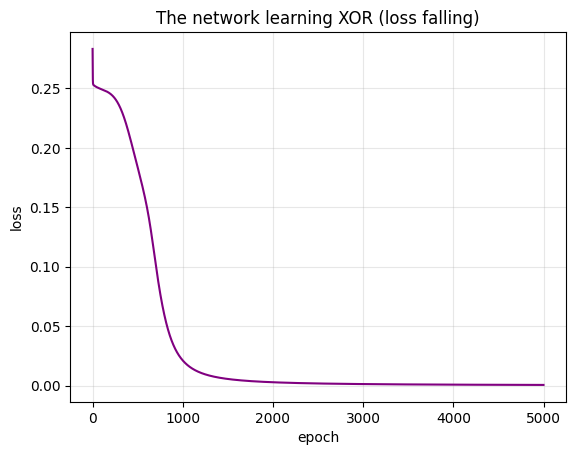

In [9]:
# watch the learning happen — the loss falling
plt.plot(history, color="purple")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("The network learning XOR (loss falling)")
plt.grid(alpha=0.3)
plt.show()

Notice the shape: the loss sits nearly **flat for a while**, then suddenly **drops** — the network struggles, then "gets it" all at once. That plateau-then-breakthrough is very typical of neural networks learning.

---
## 4. The curved boundary

Yesterday's single neuron could only draw a straight line. Let's *see* the boundary this network learned — it's **curved**, which is exactly what XOR needs.

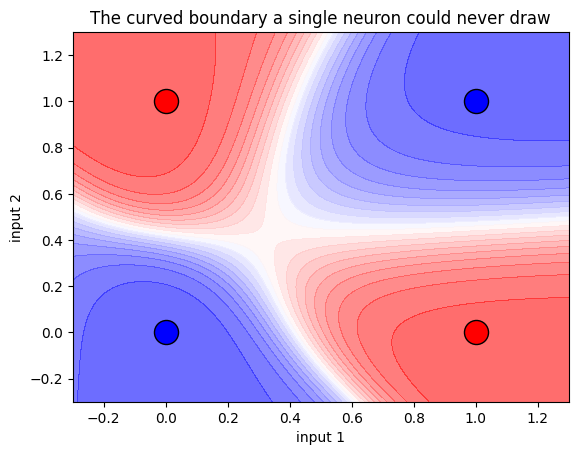

In [10]:
# ask the network to classify every point in the plane
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
_, _, _, grid_pred = forward(grid, W1, b1, W2, b2)
grid_pred = grid_pred.reshape(xx.shape)

plt.contourf(xx, yy, grid_pred, levels=20, cmap="bwr", alpha=0.6)
for i in range(4):
    color = "red" if y[i] > 0.5 else "blue"
    plt.scatter(X[i,0], X[i,1], c=color, s=300, edgecolor="k", zorder=3)
plt.title("The curved boundary a single neuron could never draw")
plt.xlabel("input 1"); plt.ylabel("input 2")
plt.show()

Look at that boundary — it **curves** to put the two red corners (output 1) in red regions and the two blue corners (output 0) in blue regions. No straight line could do this. The hidden layer gave the network the flexibility to bend the boundary exactly where XOR needs it.

**This is the payoff of the whole week.** You built — by hand, no framework — a network that learns a non-linear function through backpropagation. That's the engine inside every deep learning system, from image recognition to ChatGPT.

---
## Summary

- A **network** stacks neurons into layers: input → hidden → output. Each layer has its own weights and biases.
- The **forward pass** flows data through the layers to a prediction.
- **Backpropagation** is how it learns: the output's error is passed *backwards* to the hidden layer, and every weight gets a gradient telling it how to reduce the loss.
- The training loop is the **same four moves** as always — forward → loss → backward → update — just with two layers.
- The result: the network **solved XOR**, which a single neuron could not. The hidden layer let it draw a **curved boundary**.

You've now built the complete engine of deep learning from scratch. Every piece — neurons, layers, forward pass, loss, backprop, update — by your own hand.

**Tomorrow:** the same network in **PyTorch** — where `loss.backward()` does all the backprop you just wrote by hand, in a single line. Now that you know what it's doing, the framework is pure relief.